# Custom GW Signal Slider

This notebook walks a user through adding a **new gravitational-wave signal** from raw LIGO files and then using the slider app.

The steps are: 
1. Upload raw H1/L1 data files (32 s) and matching long files (4096 s) to this folder.
2. Build a processed data dictionary from raw files (PSD + whitening + bandpass).
3. Manually enter reference parameters for the new event.
4. Run a non-interactive matched-filter demo to understand what the fit does.
5. Launch the interactive slider app with your event replacing the last button (originally GW190519).

in READ_ME: 
# Clone repo
git clone https://github.com/your-repo/project.git
cd project

# Create environment
python -m venv gwslider-env

# Activate environment
source gwslider-env/bin/activate   # Mac/Linux
# gwslider-env\Scripts\activate    # Windows

# Install dependencies
pip install -r requirements.txt

# Make Jupyter kernel
python -m ipykernel install --user --name gwslider-env --display-name "Python (gwslider-env)"

# Launch notebook
jupyter notebook

In [1]:
# check that you are in the correct environment
import sys
print(sys.executable)

/Library/Developer/CommandLineTools/usr/bin/python3


## 1) Load in Files

Download the files for your event from the GWOSC event catalog. 

Expected files:
- `H-H1_<32s_file>.hdf5`
- `L-L1_<32s_file>.hdf5`
- `H-H1_<4096s_file>.hdf5`
- `L-L1_<4096s_file>.hdf5`


In [2]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import h5py
import pickle
from scipy.interpolate import interp1d
import readligo as rl

from signal_processing import tukey, whiten, bandpass
from widgets import make_checkboxes, make_sliders, make_button, get_comp_params, get_slider_params, remove_sliders
from matched_filter import wrapped_matched_filter
from GW_class import GWSignals, GW150914, GW190521, GW200129, GW200224, GW200311, GW191109, GW190828, GW_simulated
from constants import chi1_min, chi1_max, chi2_min, chi2_max

plt.close('all')

/Users/pipermorris/Library/Python/3.9/lib/python/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [3]:

event_name = 'user input'

# If True, this will load an existing processed dictionary -- this is for just testing the buttons to make sure they work 
use_preprocessed_example = True
preprocessed_example_path = 'data/GW150914_data_dict.pkl'

# 32-second files around merger
fn_H1_32 = 'H-H1_GWOSC_4KHZ_R1-XXXXXXXXXX-32.hdf5'
fn_L1_32 = 'L-L1_GWOSC_4KHZ_R1-XXXXXXXXXX-32.hdf5'

# 4096-second files for PSD estimation
fn_H1_4096 = 'H-H1_GWOSC_4KHZ_R1-XXXXXXXXXX-4096.hdf5'
fn_L1_4096 = 'L-L1_GWOSC_4KHZ_R1-XXXXXXXXXX-4096.hdf5'

# Event center time (GPS), and bandpass region
time_center = 1126259462.4
fband = [35.0, 350.0]

# Save path for processed dictionary (optional)
processed_dict_path = f'data/{event_name}_data_dict.pkl'


## 2) Build Data Dictionary 

The next cells does: 
- PSD estimation from the long (4096 s) files
- Whitening using `signal_processing.whiten`
- Bandpassing using `signal_processing.bandpass`


In [4]:
# this if/else can be deleted once we make sure all test work!

if use_preprocessed_example:
    with open(preprocessed_example_path, 'rb') as f:
        custom_data_dict = pickle.load(f)
    
else:

    # 1) Load 32-second strain (event window)
    strain_H1, time_H1, _ = rl.loaddata(fn_H1_32, 'H1')
    strain_L1, time_L1, _ = rl.loaddata(fn_L1_32, 'L1')
    time = time_H1

    # 2) Load 4096-second strain and build PSDs around event center
    with h5py.File(fn_H1_4096, 'r') as hdf_file:
        dt = hdf_file['strain/Strain'].attrs['Xspacing']
    fs = int(1.0 / dt)

    strain_H1_long, time_H1_long, _ = rl.loaddata(fn_H1_4096, 'H1')
    strain_L1_long, time_L1_long, _ = rl.loaddata(fn_L1_4096, 'L1')

    idx = np.where((time_H1_long >= time_center - 512) & (time_H1_long < time_center + 512))
    NFFT = int(4 * fs)
    NOVL = int(1 * NFFT / 2)
    psd_window = tukey(NFFT, alpha=1.0 / 4)

    Pxx_H1, freqs = mlab.psd(strain_H1_long[idx], Fs=fs, NFFT=NFFT, window=psd_window, noverlap=NOVL)
    Pxx_L1, freqs = mlab.psd(strain_L1_long[idx], Fs=fs, NFFT=NFFT, window=psd_window, noverlap=NOVL)

    psd_H1 = interp1d(freqs, Pxx_H1)
    psd_L1 = interp1d(freqs, Pxx_L1)
    large_data_psds = {'H1': psd_H1, 'L1': psd_L1}

    # 3) Whiten and bandpass
    strain_H1_whiten = whiten(strain_H1, large_data_psds['H1'], dt)
    strain_L1_whiten = whiten(strain_L1, large_data_psds['L1'], dt)
    strain_H1_whitenbp = bandpass(strain_H1_whiten, fband, fs)
    strain_L1_whitenbp = bandpass(strain_L1_whiten, fband, fs)

    # 4) Build dictionary and save .pkl
    custom_data_dict = {
        'H1': {
            'strain': strain_H1,
            'strain_whiten': strain_H1_whiten,
            'strain_whitenbp': strain_H1_whitenbp,
            },
        'L1': {
            'strain': strain_L1,
            'strain_whiten': strain_L1_whiten,
            'strain_whitenbp': strain_L1_whitenbp,
        },
        'time': time,
        'time_center': time_center,
        'dt': dt,
        'fs': fs,
        'large_data_psds': large_data_psds,
    }

    # open .pkl file
    with open(processed_dict_path, 'wb') as f:
        pickle.dump(custom_data_dict, f)


## 3) Add Reference Parameters and Create Time Window

Set event parameters manually in this order:
- `[mass1, mass2, chi_plus, chi_minus]`

IMPORTANT: the source masses are used so you should multiply each mass by (1+z)

In [5]:
user_ref_params = [38.8, 33.0, -0.04, 0.0]

# uses a temporary window so matched-filter timing can be measured
GW_custom = GWSignals(user_ref_params, custom_data_dict, t_min=-0.2, t_max=0.2)

# Find merger time in the matched-filter fit
fit_ref, data_ref, times_ref, *_ = wrapped_matched_filter(GW_custom.comp_params.copy(), GW_custom, 'H1')
t_peak = times_ref[np.argmax(np.abs(fit_ref))]

# Convert total mass to seconds for calculating time window to use in plot
M_sec = (user_ref_params[0] + user_ref_params[1]) * 4.925e-6
left = 350 * M_sec
right = 200 * M_sec

# minimum time for plotting window, maximum time for plotting window
t_min = max(times_ref.min(), t_peak - left)
t_max = min(times_ref.max(), t_peak + right)

# Rebuil GW_custom with correct window
GW_custom = GWSignals(user_ref_params, custom_data_dict, t_min=t_min, t_max=t_max)



## 4) Matched Filter 

`wrapped_matched_filter(params, GW_signal, det)` does this:
1. Builds an IMRPhenomD template waveform from the given parameters
2. Normalizes it with the detector PSD.
3. Finds the best time/phase shift and amplitude in the data.
4. Returns best-fit template, data segment, and peak SNR (`rho`).

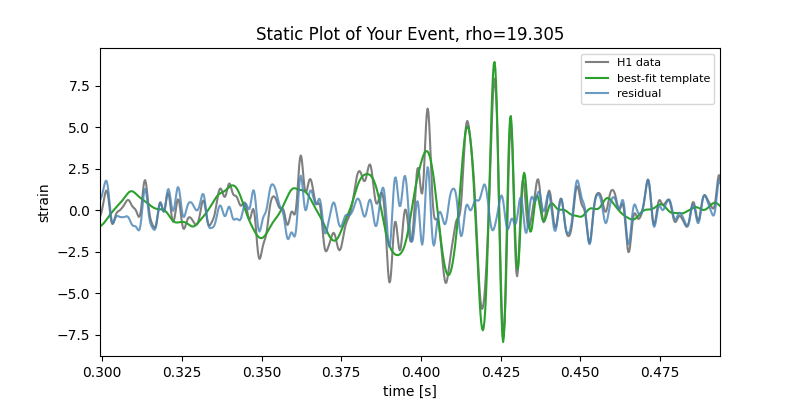

In [6]:
trial_params = GW_custom.comp_params.copy() # this is just for testing, this 
det = 'H1'

# trial_params will be replaced with "reference params" when we are done with testing
fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(trial_params, GW_custom, det)
residual = data - fit

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, data, color='black', alpha=0.5, label=f'{det} data')
ax.plot(times, fit, color='C2', label='best-fit template')
ax.plot(times, residual, color='steelblue', alpha=0.8, label='residual')
ax.set_xlabel('time [s]')
ax.set_ylabel('strain')
ax.set_xlim(t_min, t_max)
ax.set_title(f'Static Plot of Your Event, rho={SNRmax:.3f}')
ax.legend(fontsize=8)
plt.show()


## 5) Interactive Slider App 

This launches the slider UI.
The last button under the "use_real_data" checkbox is your custom event.

In [7]:
# def launch_slider_with_custom_last_button(GW_custom, custom_label='USER_EVENT'):
#     plt.close('all')
#     fig, ax = plt.subplots(figsize=(5, 3), dpi=160)
#     fig.subplots_adjust(left=0.33, bottom=0.34, right=0.97, top=0.98)

#     checkboxes, buttons, buttons1, buttons2, buttons3, buttons4, buttons5, buttons6, buttons7 = make_checkboxes(fig)
#     buttons7.label.set_text(custom_label)

#     selected_real_signal = GW150914
#     GW_signal = GW_simulated
#     det = 'H1'

#     slider_axes, sliders = make_sliders(fig, checkboxes, GW_signal.comp_params)
#     slider_cids = []
#     button = make_button(fig)

#     init_params = get_comp_params(sliders)
#     fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
#     residuals = data - fit

#     data_line, = ax.plot(times, data, color='black', label=f'{det} data', alpha=0.5, linewidth=0.8)
#     fit_line, = ax.plot(times, fit, color='C2', label='fit', linewidth=0.8)
#     residual_line, = ax.plot(times, residuals, color='steelblue', alpha=0.8, label='residual', linewidth=0.8)
#     residual_line.set_visible(False)

#     ax.set_xlabel('time [s]', fontsize=6)
#     ax.set_ylabel('strain', fontsize=6)
#     ax.tick_params(axis='both', labelsize=5)
#     ax.legend(loc='upper left', fontsize=6)

#     xlims = {
#         'SIMULATED': (0.30, 0.50),
#         'GW150914': (0.30, 0.50),
#         'GW190521': (-0.05, 0.13),
#         'GW200129': (-0.10, 0.10),
#         'GW200224': (-0.15, 0.075),
#         'GW200311': (-0.10, 0.20),
#         'GW191109': (-0.10, 0.10),
#         'GW190828': (-0.15, 0.15),
#         custom_label: (t_min, t_max),
#     }

#     def current_event_label(current_signal):
#         if current_signal is GW_simulated:
#             return 'SIMULATED'
#         if current_signal is GW150914:
#             return 'GW150914'
#         if current_signal is GW190521:
#             return 'GW190521'
#         if current_signal is GW200129:
#             return 'GW200129'
#         if current_signal is GW200224:
#             return 'GW200224'
#         if current_signal is GW200311:
#             return 'GW200311'
#         if current_signal is GW191109:
#             return 'GW191109'
#         if current_signal is GW190828:
#             return 'GW190828'
#         return custom_label

#     def set_axes_from_data(event_label, data_vals):
#         xl = xlims.get(event_label, (-0.1, 0.1))
#         ymax = np.max(np.abs(data_vals))
#         ax.set_xlim(*xl)
#         ax.set_ylim(-1.2 * ymax, 1.2 * ymax)

#     error_text = fig.text(0.05, 0.1, 'Spins not in domain.', transform=ax.transAxes)
#     error_text.set_visible(False)

#     chi_text = fig.text(0.35, 0.35, rf'$\rho = {round(SNRmax, 3)}$')
#     chi_text.set_fontsize(7)

#     signal_buttons = [buttons, buttons1, buttons2, buttons3, buttons4, buttons5, buttons6, buttons7]
#     for btn in signal_buttons:
#         btn.hovercolor = '0.9'
#         btn.color = '0.97'

#     def on_button_click(button_to_change):
#         for button_obj in signal_buttons:
#             button_obj.color = '0.97'
#         button_to_change.color = 'C2'
#         fig.canvas.draw_idle()

#     def checkbox_update(val):
#         nonlocal slider_axes, sliders, det, GW_signal, selected_real_signal

#         if len(sliders) == 0:
#             return

#         slider_val = get_comp_params(sliders)
#         spins_valid = (chi1_min <= slider_val[2] <= chi1_max and chi2_min <= slider_val[3] <= chi2_max)

#         remove_sliders(slider_axes, sliders)

#         det = 'L1' if checkboxes.get_status()[3] else 'H1'
#         data_line.set_label(f'{det} data')

#         real_data_checked = checkboxes.get_status()[2]
#         residuals_checked = checkboxes.get_status()[4]

#         if spins_valid:
#             GW_signal = selected_real_signal if real_data_checked else GW_simulated
#             fit_v, data_v, times_v, SNR_v, amp_v, phase_v = wrapped_matched_filter(slider_val, GW_signal, det)
#             residuals_v = data_v - fit_v

#             data_line.set_xdata(times_v)
#             data_line.set_ydata(data_v)
#             fit_line.set_xdata(times_v)
#             fit_line.set_ydata(fit_v)
#             residual_line.set_xdata(times_v)
#             residual_line.set_ydata(residuals_v)
#             residual_line.set_visible(bool(residuals_checked))

#             chi_text.set_visible(True)
#             error_text.set_visible(False)
#             chi_text.set_text(rf'$\rho = {round(SNR_v, 3)}$')
#             set_axes_from_data(current_event_label(GW_signal), data_v)
#         else:
#             error_text.set_visible(True)
#             chi_text.set_visible(False)

#         ax.legend(loc='upper left', fontsize=6)
#         ax.tick_params(axis='both', labelsize=6)

#         slider_axes, sliders = make_sliders(fig, checkboxes, GW_signal.comp_params, slider_val)
#         for slider in sliders:
#             slider.ax.get_lines()[0].set_visible(False)

#         slider_cids.clear()
#         slider_cids.append(sliders[0].on_changed(slider_update))
#         slider_cids.append(sliders[1].on_changed(slider_update))
#         slider_cids.append(sliders[2].on_changed(slider_update))
#         slider_cids.append(sliders[3].on_changed(slider_update))

#         slider_update(val)
#         fig.canvas.draw_idle()

#     def slider_update(val):
#         params = get_comp_params(sliders)
#         residual_checked = checkboxes.get_status()[4]

#         if params[2] < chi1_min or params[2] > chi1_max or params[3] < chi2_min or params[3] > chi2_max:
#             times_v = data_line.get_xdata()
#             data_v = data_line.get_ydata()
#             zero_fit = np.zeros_like(data_v)
#             fit_line.set_data(times_v, zero_fit)
#             residual_line.set_data(times_v, data_v - zero_fit)
#             residual_line.set_visible(bool(residual_checked))
#             error_text.set_visible(True)
#             chi_text.set_visible(False)
#         else:
#             fit_v, data_v, times_v, SNR_v, amp_v, phase_v = wrapped_matched_filter(params, GW_signal, det)
#             residuals_v = data_v - fit_v

#             sliders[4].set_val(amp_v)
#             sliders[5].set_val(phase_v)
#             sliders[4].set_active(False)
#             sliders[5].set_active(False)

#             fit_line.set_xdata(times_v)
#             fit_line.set_ydata(fit_v)
#             residual_line.set_xdata(times_v)
#             residual_line.set_ydata(residuals_v)
#             residual_line.set_visible(bool(residual_checked))
#             data_line.set_xdata(times_v)
#             data_line.set_ydata(data_v)
#             chi_text.set_visible(True)
#             error_text.set_visible(False)
#             chi_text.set_text(rf'$\rho = {round(SNR_v, 3)}$')
#             set_axes_from_data(current_event_label(GW_signal), data_v)

#         fig.canvas.draw_idle()

#     def button_push(event):
#         chirp_q_checked, plus_minus_checked, _, _, _ = checkboxes.get_status()

#         if chirp_q_checked:
#             sliders[0].set_val(GW_signal.chirp)
#             sliders[1].set_val(GW_signal.ratio)
#         else:
#             sliders[0].set_val(GW_signal.mass1)
#             sliders[1].set_val(GW_signal.mass2)

#         if plus_minus_checked:
#             sliders[2].set_val(GW_signal.chiPlus)
#             sliders[3].set_val(GW_signal.chiMinus)
#         else:
#             sliders[2].set_val(GW_signal.chi1)
#             sliders[3].set_val(GW_signal.chi2)

#         slider_update(event)
#         checkbox_update(None)
#         fig.canvas.draw_idle()

#     def switch_event(new_signal, button_obj):
#         nonlocal GW_signal, selected_real_signal
#         selected_real_signal = new_signal
#         on_button_click(button_obj)
#         GW_signal = selected_real_signal if checkboxes.get_status()[2] else GW_simulated
#         checkbox_update(None)

#     slider_cids.append(sliders[0].on_changed(slider_update))
#     slider_cids.append(sliders[1].on_changed(slider_update))
#     slider_cids.append(sliders[2].on_changed(slider_update))
#     slider_cids.append(sliders[3].on_changed(slider_update))

#     checkboxes.on_clicked(checkbox_update)
#     button.on_clicked(button_push)

#     buttons.on_clicked(lambda event: switch_event(GW150914, buttons))
#     buttons1.on_clicked(lambda event: switch_event(GW190521, buttons1))
#     buttons2.on_clicked(lambda event: switch_event(GW200129, buttons2))
#     buttons3.on_clicked(lambda event: switch_event(GW200224, buttons3))
#     buttons4.on_clicked(lambda event: switch_event(GW200311, buttons4))
#     buttons5.on_clicked(lambda event: switch_event(GW191109, buttons5))
#     buttons6.on_clicked(lambda event: switch_event(GW190828, buttons6))
#     buttons7.on_clicked(lambda event: switch_event(GW_custom, buttons7))

#     set_axes_from_data(current_event_label(GW_signal), data)
#     plt.show()


# launch_slider_with_custom_last_button(GW_custom, custom_label=event_name)


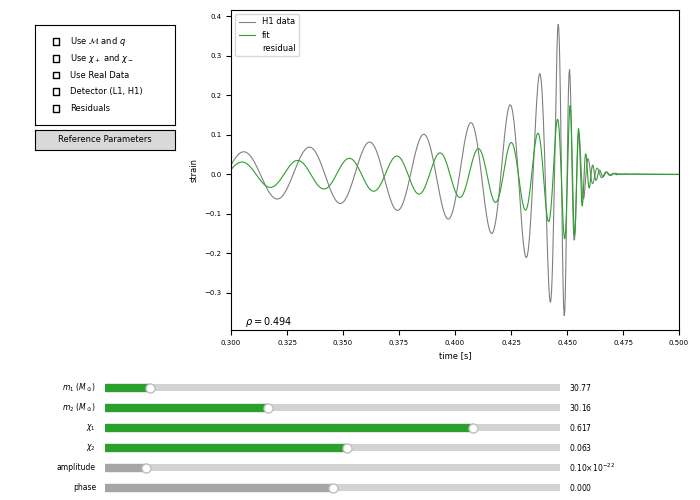

In [36]:
from widgets import *


# setup main plot
fig, ax = plt.subplots(figsize=(7, 5))

# adjust plot area
fig.subplots_adjust(left=0.33, bottom=0.34, right=0.97, top=0.98)

# make checkboxes
checkboxes, buttons, buttons1, buttons2, buttons3, buttons4, buttons5, buttons6, buttons7 = make_checkboxes(fig)

# start off using simulated data
GW_signal = GW_simulated
# start off with Hanford detector 
det = 'H1'
# make sliders
slider_axes, sliders = make_sliders(fig, checkboxes, GW_signal.comp_params)
slider_cids = []

# make button to go to reference parameters
button = make_button(fig)

# get initial parameters
init_params = get_comp_params(sliders)

# plot data and fit
fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
residuals = data - fit
data_line, = ax.plot(times, data, color='Black', label=f'{det} data', alpha=0.5, linewidth=0.8)
fit_line, = ax.plot(times, fit, color='C2', label='fit', linewidth=0.8)
residual_line, = ax.plot(times, residuals, color= 'steelblue', alpha= 0.8,label= 'residual', linewidth=0.8)
residual_line.set_visible(False)
ax.set_xlabel('time [s]', fontsize=6)
ax.set_ylabel('strain', fontsize=6)
ax.tick_params(axis='both', labelsize=5)
ax.legend(loc='upper left', fontsize=6)
ax.set_xlim(0.30, 0.50)

# make error message if spins are outside domain
error_text = fig.text(0.05, 0.1, 'Spins not in domain.', transform=ax.transAxes)
error_text.set_visible(False)

#chi-squared text box 
chi_text = fig.text(0.35, 0.35, rf'$\rho = {round(SNRmax, 3)}$')
chi_text.set_fontsize(7)

def launch_slider_with_custom_last_button(GW_custom, custom_label='USER_EVENT'):
    
  
    buttons7.label.set_text(custom_label)

    # function to handle checkbox changes
    def checkbox_update(val):
        global slider_axes, sliders

        # if sliders are already removed, skip
        if len(sliders) == 0:
            return
        
        slider_val = get_comp_params(sliders)
        
        # Check if spins are valid
        spins_valid = (slider_val[2] >= chi1_min and slider_val[2] <= chi1_max and 
                    slider_val[3] >= chi2_min and slider_val[3] <= chi2_max)

        # remove old sliders
        remove_sliders(slider_axes, sliders)
        # store current detector 
        global det, data_line, residual_line
        # checkbox that switches detector data
        det = 'L1' if checkboxes.get_status()[3] else 'H1'
        ax.legend(loc='upper left', fontsize=6)
        # update label
        data_line.set_label(f'{det} data')
        # check if using real data or not
        real_data_checked = checkboxes.get_status()[2]  
        residuals_checked= checkboxes.get_status()[4]
        # ensure parameters and plot don't update when checkboxes clicked
        if spins_valid:
            if not real_data_checked:
                global GW_signal
                GW_signal = GW_simulated
                fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(slider_val, GW_signal, det)
                data_line.set_xdata(times)
                data_line.set_ydata(data)
                ymax = np.max(np.abs(data))
                ax.set_xlim(0.30, 0.50)
                ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
            # show residuals plot when checkbox clicked
            if residuals_checked:
                fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(slider_val, GW_signal, det)
                residuals= data - fit
                residual_line.set_xdata(times)
                residual_line.set_ydata(residuals)
                residual_line.set_visible(True)
            else:   
                residual_line.set_visible(False) 

            # update data which is plotted
            fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(slider_val, GW_signal, det)
            data_line.set_xdata(times)
            data_line.set_ydata(data)
            ymax = np.max(np.abs(data))
            ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        else:
            print("Spins out of range, skipping data update in checkbox_update")
        # Rebuild legend in same location
        ax.legend(loc='upper left', fontsize=6)
        ax.tick_params(axis='both', labelsize=6)

        # make new slider
        slider_axes, sliders = make_sliders(fig, checkboxes, GW_signal.comp_params, slider_val)
        # remove initial position ticks on each slider
        for slider in sliders:
            slider.ax.get_lines()[0].set_visible(False)
        

        # # Disconnect old sliders
        slider_cids.clear() 
        # Reconnect to new sliders
        slider_cids.append(sliders[0].on_changed(slider_update))
        slider_cids.append(sliders[1].on_changed(slider_update))
        slider_cids.append(sliders[2].on_changed(slider_update))
        slider_cids.append(sliders[3].on_changed(slider_update))
        
        # update data plotted
        slider_update(val)
        fig.canvas.draw_idle()
        return

    # function to handle slider changes
    def slider_update(val):
        chirp_q_checked, plus_minus_checked, real_data_checked, det_checked, residual_checked= checkboxes.get_status()
        # get component parameters
        params = get_comp_params(sliders)
        # check if spins are in domain, if they are outside of domain display error message
        if params[2] < chi1_min or params[2] > chi1_max or params[3] < chi2_min or params[3] > chi2_max:
            #fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(params, GW_signal, det)
            times = data_line.get_xdata()
            data = data_line.get_ydata()
            # if out of range, zero out data
            zero_fit = np.zeros_like(data)
            fit_line.set_data(times, zero_fit)
            residuals = data - zero_fit
            residual_line.set_data(times, residuals)
            # show error text
            error_text.set_visible(True)
            chi_text.set_visible(False)
        elif real_data_checked:
            # update sliders, data and fit when real data is checked
            fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(params, GW_signal, det)
            residuals = data - fit

            # "freeze" amp and phase sliders
            sliders[4].set_val(amp)
            sliders[5].set_val(phase)
            sliders[4].set_active(False)
            sliders[5].set_active(False)

            fit_line.set_ydata(fit)
            residual_line.set_ydata(residuals)
            chi_text.set_visible(True)
            error_text.set_visible(False)
            chi_text.set_text(rf'$\rho = {round(SNRmax, 3)}$')
        else:
            # if real data is not checked, set signal to simulated data
            fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(params, GW_signal, det)
            residuals = data - fit

            # "freeze amp and phase sliders"
            sliders[4].set_val(amp)
            sliders[5].set_val(phase)
            sliders[4].set_active(False)
            sliders[5].set_active(False)

            fit_line.set_ydata(fit)
            residual_line.set_ydata(residuals)
            chi_text.set_visible(True)
            error_text.set_visible(False)
            chi_text.set_text(rf'$\rho = {round(SNRmax, 3)}$')
        fig.canvas.draw_idle()
        return


    # function to send sliders to reference parameters
    def button_push(event):
        # get status of checkboxes
        chirp_q_checked, plus_minus_checked, real_data_checked, det_checked, residual_checked = checkboxes.get_status()
        # move sliders to injected value
        if chirp_q_checked:
            sliders[0].set_val(GW_signal.chirp)
            sliders[1].set_val(GW_signal.ratio)
        else:
            sliders[0].set_val(GW_signal.mass1)
            sliders[1].set_val(GW_signal.mass2)

        if plus_minus_checked:
            sliders[2].set_val(GW_signal.chiPlus)
            sliders[3].set_val(GW_signal.chiMinus)
        else:
            sliders[2].set_val(GW_signal.chi1)
            sliders[3].set_val(GW_signal.chi2)
        slider_update(event)
        fig.canvas.draw_idle()
        return

    # function to update plot when GW150914 button clicked
    def button_push_signals(event):
        global GW_signal
        GW_signal =  GW150914
        on_button_click(event, buttons)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(0.30, 0.5)
        ax.set_ylim(-1.2 * ymax, 1.2 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW190521 button clicked
    def button_push_signals1(event):
        global GW_signal
        GW_signal=  GW190521
        on_button_click(event, buttons1)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.05, 0.13)
        ax.set_ylim(-1.2 * ymax, 1.2 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW200129 button clicked
    def button_push_signals2(event):
        global GW_signal
        GW_signal = GW200129
        on_button_click(event, buttons2)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residuals = data - fit
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.10, 0.10)
        ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW200224 button clicked
    def button_push_signals3(event):
        global GW_signal
        GW_signal = GW200224
        on_button_click(event, buttons3)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.15, 0.075)
        ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW200311 button clicked
    def button_push_signals4(event):
        global GW_signal
        GW_signal = GW200311
        on_button_click(event, buttons4)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.10, 0.2)
        ax.set_ylim(-1.2 * ymax, 1.2 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW191109 button clicked
    def button_push_signals5(event):
        global GW_signal
        GW_signal = GW191109
        on_button_click(event, buttons5)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.10, 0.10)
        ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW190828 button clicked
    def button_push_signals6(event):
        global GW_signal
        GW_signal = GW190828
        on_button_click(event, buttons6)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(-0.15, 0.15)
        ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        fig.canvas.draw_idle()
        return 

    # function to update plot when GW190519 button clicked
    def button_push_signals7(event):
        global GW_signal
        GW_signal = GW_custom
        on_button_click(event, buttons7)
        fit, data, times, SNRmax, amp, phase = wrapped_matched_filter(init_params, GW_signal, det)
        residuals = data - fit
        data_line.set_xdata(times)
        data_line.set_ydata(data)
        residual_line.set_xdata(times)
        residual_line.set_ydata(residuals)
        checkbox_update(event)
        ymax = np.max(np.abs(data))
        ax.set_xlim(t_min, t_max)
        ax.set_ylim(-1.1 * ymax, 1.1 * ymax)
        fig.canvas.draw_idle()
        return 



    # update plot as sliders move
    slider_cids.append(sliders[0].on_changed(slider_update))
    slider_cids.append(sliders[1].on_changed(slider_update))
    slider_cids.append(sliders[2].on_changed(slider_update))
    slider_cids.append(sliders[3].on_changed(slider_update))

    # update plots when checkboxes changed
    checkboxes.on_clicked(checkbox_update)


    # connect button push functions to buttons
    button.on_clicked(button_push)
    buttons.on_clicked(button_push_signals)
    buttons1.on_clicked(button_push_signals1)
    buttons2.on_clicked(button_push_signals2)
    buttons3.on_clicked(button_push_signals3)
    buttons4.on_clicked(button_push_signals4)
    buttons5.on_clicked(button_push_signals5)
    buttons6.on_clicked(button_push_signals6)
    buttons7.on_clicked(button_push_signals7)
    signal_buttons = [buttons, buttons1, buttons2, buttons3, buttons4, buttons5, buttons6, buttons7]


    # function to have buttons change color when clicked 
    def on_button_click(event, button_to_change):
        for button_obj in signal_buttons:
            button_obj.color = '0.97'
        
        button_to_change.color = 'C2' 
        fig.canvas.draw_idle() 
        return
    
launch_slider_with_custom_last_button(GW_custom, custom_label=event_name)